# Project - 1 Sales analysis
1. Use a retail/sales dataset to answer business questions (top products, seasonality).
2. Compute KPIs: total revenue, average order value, top regions.
3. Visualize trends, top products, and present recommendations.
4. Export a one-page summary with charts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110

In [2]:
path = "Superstore.csv"
data = pd.read_csv(path, encoding="latin1")
data.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [3]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["month"] = data["Order Date"].dt.to_period("M").dt.to_timestamp()
data["year"] = data["Order Date"].dt.year

### KPIs

In [4]:
total_revenue = data["Sales"].sum()
n_orders = data["Order ID"].nunique()
aov = total_revenue / n_orders
top_regions = data.groupby("Region")["Sales"].sum().sort_values(ascending=False)
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(5)
monthly_revenue = data.groupby("month")["Sales"].sum()
has_profit = "profit" in data.columns
total_profit = data["profit"].sum() if has_profit else None
margin_pct = (total_profit / total_revenue * 100) if has_profit else None

In [5]:
print("KPIs")
print(f"Total Revenue:      ${total_revenue:,.2f}")
print(f"Total Orders:        {n_orders:,}")
print(f"Average Order Value: ${aov:,.2f}")

KPIs
Total Revenue:      $2,297,200.86
Total Orders:        5,009
Average Order Value: $458.61


In [6]:
print("Top 5 products by revenue:")
print(top_products.to_string())

Top 5 products by revenue:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479


In [7]:
print("Top region:", top_regions.index[0], f"(${top_regions.iloc[0]:,.0f})")

Top region: West ($725,458)


In [8]:
category_margin = data.groupby("Category").agg(revenue=("Sales", "sum"), profit=("Profit", "sum"))
category_margin["margin_pct"] = (category_margin["profit"] / category_margin["revenue"] * 100).round(1)
print("Revenue vs margin by category:")
print(category_margin.sort_values("revenue", ascending=False).to_string())

Revenue vs margin by category:
                     revenue       profit  margin_pct
Category                                             
Technology       836154.0330  145454.9481        17.4
Furniture        741999.7953   18451.2728         2.5
Office Supplies  719047.0320  122490.8008        17.0


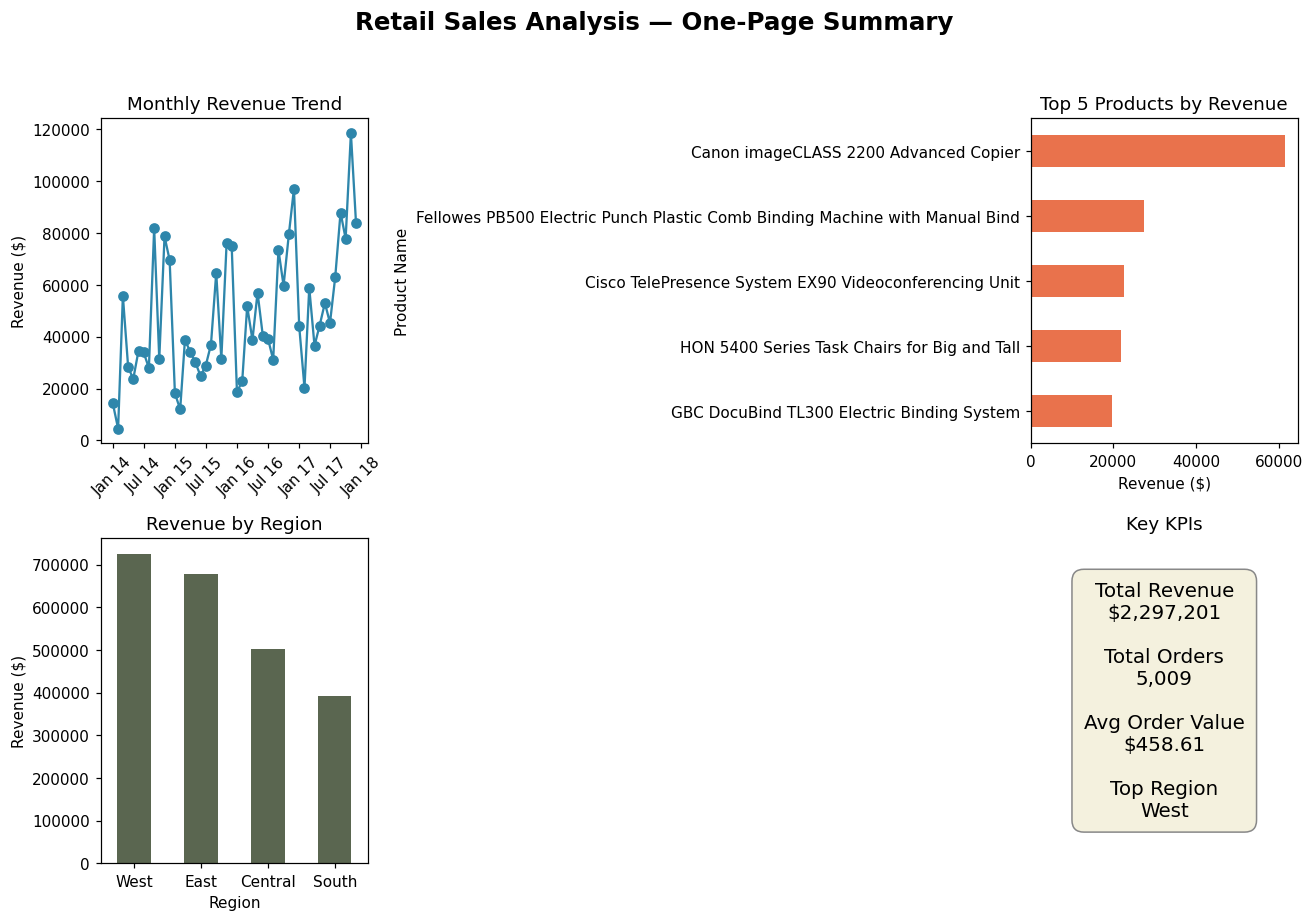

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
fig.suptitle("Retail Sales Analysis — One-Page Summary", fontsize=16, fontweight="bold")

# Monthly revenue trend (seasonality)
ax = axes[0, 0]
ax.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="#2E86AB")
ax.set_title("Monthly Revenue Trend")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Revenue ($)")

# Top products
ax = axes[0, 1]
top_products.sort_values().plot(kind="barh", ax=ax, color="#E9724C")
ax.set_title("Top 5 Products by Revenue")
ax.set_xlabel("Revenue ($)")

# Revenue by region
ax = axes[1, 0]
top_regions.plot(kind="bar", ax=ax, color="#5A6650")
ax.set_title("Revenue by Region")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=0)

# KPI text panel
ax = axes[1, 1]
ax.axis("off")
kpi_lines = [
    f"Total Revenue\n${total_revenue:,.0f}",
    f"Total Orders\n{n_orders:,}",
    f"Avg Order Value\n${aov:,.2f}",
]
kpi_lines.append(f"Top Region\n{top_regions.index[0]}")
kpi_text = "\n\n".join(kpi_lines)
ax.text(0.5, 0.5, kpi_text, ha="center", va="center", fontsize=13,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#F4F1DE", edgecolor="#888"))
ax.set_title("Key KPIs")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("sales_summary.png", bbox_inches="tight")

In [10]:
print("Recommendations")
print(f"1. Focus on {top_regions.index[0]}, the highest-revenue region, "
      f"and try to understand why {top_regions.index[-1]} underperforming.")
print(f"2. Promote '{top_products.index[0]}', it generated the most sales revenue.")
best_month = monthly_revenue.idxmax().strftime("%B %Y")
print(f"3. Forecast staff/inventory for peak {best_month} it suggests the product is seasonal.")

Recommendations
1. Focus on West, the highest-revenue region, and try to understand why South underperforming.
2. Promote 'Canon imageCLASS 2200 Advanced Copier', it generated the most sales revenue.
3. Forecast staff/inventory for peak November 2017 it suggests the product is seasonal.
